# Exploring `base_network.py` outputs

This jupyter notebook analyse the `base_network.py` **outputs**.

The `pypsa-earth/Snakefile` explicitly list in the **rule** what goes into the function `base_network.py` and what goes out (`networks/base.nc`). When inputs are commented out (#) than they are currently not considered. Maybe you want to delete them, make them run or develop new features? What can be observed from the inputs is that the script creates a connected network topology with the network data and shapes of the region.

```
rule base_network:
    input:
        osm_buses="data/base_network/africa_all_buses_build_network.csv",
        osm_lines="data/base_network/africa_all_lines_build_network.csv",
        country_shapes='resources/country_shapes.geojson',
        offshore_shapes='resources/offshore_shapes.geojson',
        # eg = ENTSO-E Gridkit
        # eg_buses='data/entsoegridkit/buses.csv',
        # eg_lines='data/entsoegridkit/lines.csv',
        # eg_links='data/entsoegridkit/links.csv',
        # eg_converters='data/entsoegridkit/converters.csv',
        # eg_transformers='data/entsoegridkit/transformers.csv',
        # parameter_corrections='data/parameter_corrections.yaml',
        # links_p_nom='data/links_p_nom.csv',
        # links_tyndp='data/links_tyndp.csv',
        # africa_shape='resources/africa_shape.geojson'
    output:
        "networks/base.nc",
    log:
        "logs/base_network.log",
    benchmark:
        "benchmarks/base_network"
    threads: 1
    resources:
        mem=500,
    script:
        "scripts/base_network.py"
```

Before analysing the outputs of add_electricity.py check that:
- `pypsa-earth` environment (/kernel) in jupyter notebook  is active and updated
- root folder where pypsa-earth is installed is named "pypsa-earth"
- or rename the below `sets_path_to_root("<folder_name>")` accordingly

In [1]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

A jupyter notebook requires the user to import all they need. So we need to import all the required dependencies from the `pypsa-earth` environment:

In [2]:
import logging
import os

import pypsa
import yaml
import pandas as pd
import geopandas as gpd
import geoviews as gv
import hvplot.pandas
import numpy as np
import scipy as sp
import networkx as nx
import matplotlib as plt

from scipy.sparse import csgraph
from itertools import product

from shapely.geometry import Point, LineString
import shapely, shapely.prepared, shapely.wkt
import shapely
import warnings
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) # Ignore Shapely warnings

logger = logging.getLogger(__name__)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

## Network analysis

Now let's import the output file which should be in i.e. `~/pypsa-earth/networks/base.nc`. 

Note: If you don't have the /elec.nc file yet in your folder structure, you could try to generate it from the terminal. In this case set the path so that you are located at `~/pypsa-earth`. Once you are there, use the command:
```
snakemake -j 1 networks/base.nc
```
Note that this is something you can to for any other rule to generate it's outputs `snakemake -j 1 <output of rule>`

In [16]:
scenario_name = "KE_customPP"

scenario_subpath = scenario_name + "/" if scenario_name else ""

network_path = os.getcwd() + "/pypsa-earth/networks" + "/" + scenario_subpath + "/base.nc"
n = pypsa.Network(network_path)
n

Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'transf_15_0', 'transf_15_1', 'transf_16_0', 'transf_17_0',
       'transf_18_0', 'transf_22_0', 'transf_22_1', 'transf_24_0',
       'transf_26_0', 'transf_27_0', 'transf_32_0', 'transf_34_0',
       'transf_69_0'],
      dtype='object', name='name')
Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'transf_15_0', 'transf_15_1', 'transf_16_0', 'transf_17_0',
       'transf_18_0', 'transf_22_0', 'transf_22_1', 'transf_24_0',
       'transf_26_0', 'transf_27_0', 'transf_32_0', 'transf_34_0',
       'transf_69_0'],
      dtype='object', name='name')
Index(['transf_0_0', 'transf_2_0', 'transf_4_0', 'transf_5_0', 'transf_6_0',
       'transf_7_0', 'transf_8_0', 'transf_10_0', 'transf_10_1', 'transf_12_0',
       'tra

PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 105
 - Line: 92
 - Link: 1
 - Transformer: 23
Snapshots: 8760

You might be interested to see what's in the Network Common Data Form or NetCDF (.nc) file. To assess that we use **xarray**

In [10]:
import xarray as xr

path = network_path
network_data = xr.open_dataset(path)
network_data

<xarray.Dataset> Size: 12MB
Dimensions:                       (snapshots: 8760, investment_periods: 0,
                                   lines_i: 92, buses_i: 105, links_i: 1,
                                   transformers_i: 23)
Coordinates:
  * snapshots                     (snapshots) int64 70kB 0 1 2 ... 8758 8759
  * investment_periods            (investment_periods) int64 0B 
  * lines_i                       (lines_i) <U2 736B '0' '1' '2' ... '86' '87'
  * buses_i                       (buses_i) <U3 1kB '0' '1' '2' ... '103' '104'
  * links_i                       (links_i) <U13 52B 'convert_26_46'
  * transformers_i                (transformers_i) <U11 1kB 'transf_0_0' ... ...
Data variables: (12/70)
    snapshots_snapshot            (snapshots) datetime64[ns] 70kB ...
    snapshots_objective           (snapshots) float64 70kB ...
    snapshots_stores              (snapshots) float64 70kB ...
    snapshots_generators          (snapshots) float64 70kB ...
    investment_periods_objective  (investment_periods) float64 0B ...
    investment_periods_years      (investment_periods) float64 0B ...
    ...                            ...
    transformers_bus1_lat         (transformers_i) float64 184B ...
    transformers_x                (transformers_i) float64 184B ...
    transformers_s_nom            (transformers_i) float64 184B ...
    transformers_tap_side         (transformers_i) int64 184B ...
    transformers_tap_position     (transformers_i) int64 184B ...
    transformers_build_year       (transformers_i) int64 184B ...
Attributes:
    network_name:           PyPSA-Earth
    network_pypsa_version:  0.30.3
    network_srid:           4326
    crs:                    {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geo...
    meta:                   {"version": "0.6.0", "tutorial": false, "logging"...

In [11]:
n.buses.head(5)

,v_nom,symbol,under_construction,tag_substation,tag_area,lon,lat,country,substation_lv,carrier,x,y,substation_off,type,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
Bus,,,,,,,,,,,,,,,,,,,,,
0,132.0,substation,False,transmission,0.0,36.9150,-1.2589,KE,True,AC,36.9150,-1.2589,True,,,1.0,0.0,inf,PQ,,
1,220.0,substation,False,transmission,0.0,36.9160,-1.2579,KE,False,AC,36.9160,-1.2579,True,,,1.0,0.0,inf,PQ,,
2,132.0,substation,False,transmission,0.0,35.2630,0.5008,KE,True,AC,35.2630,0.5008,True,,,1.0,0.0,inf,PQ,,
3,132.0,substation,False,transmission,0.0,37.6867,-0.8067,KE,True,AC,37.6867,-0.8067,True,,,1.0,0.0,inf,PQ,,
4,220.0,substation,False,transmission,0.0,37.6877,-0.8057,KE,False,AC,37.6877,-0.8057,True,,,1.0,0.0,inf,PQ,,


In [13]:
n.transformers

,Unnamed: 0,bus0,bus1,voltage_bus0,voltage_bus1,country,geometry,bounds,bus_0_coors,bus_1_coors,bus0_lon,bus0_lat,bus1_lon,bus1_lat,x,s_nom,tap_side,tap_position,build_year,type,model,r,g,b,s_nom_mod,s_nom_extendable,s_nom_min,s_nom_max,s_max_pu,capital_cost,num_parallel,tap_ratio,phase_shift,lifetime,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Transformer,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
transf_0_0,92,0,1,132000,220000,KE,"LINESTRING (36.915 -1.2589, 36.916 -1.2579)","MULTIPOINT ((36.915 -1.2589), (36.916 -1.2579))",POINT (36.915 -1.2589),POINT (36.916 -1.2579),36.9150,-1.2589,36.9160,-1.2579,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_2_0,93,3,4,132000,220000,KE,"LINESTRING (37.6867 -0.8067, 37.6877 -0.8057)","MULTIPOINT ((37.6867 -0.8067), (37.6877 -0.8057))",POINT (37.6867 -0.8067),POINT (37.6877 -0.8057),37.6867,-0.8067,37.6877,-0.8057,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_4_0,94,6,7,132000,220000,KE,"LINESTRING (37.0514 -1.0617, 37.0524 -1.0607)","MULTIPOINT ((37.0514 -1.0617), (37.0524 -1.0607))",POINT (37.0514 -1.0617),POINT (37.0524 -1.0607),37.0514,-1.0617,37.0524,-1.0607,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_5_0,95,8,9,66000,220000,KE,"LINESTRING (36.9445 -1.1649, 36.9455 -1.1639)","MULTIPOINT ((36.9445 -1.1649), (36.9455 -1.1639))",POINT (36.9445 -1.1649),POINT (36.9455 -1.1639),36.9445,-1.1649,36.9455,-1.1639,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_6_0,96,10,11,132000,220000,KE,"LINESTRING (36.3182 -0.8913, 36.3192 -0.8903)","MULTIPOINT ((36.3182 -0.8913), (36.3192 -0.8903))",POINT (36.3182 -0.8913),POINT (36.3192 -0.8903),36.3182,-0.8913,36.3192,-0.8903,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_7_0,97,12,13,33000,400000,KE,"LINESTRING (36.7963 2.4893, 36.7973 2.4903)","MULTIPOINT ((36.7963 2.4893), (36.7973 2.4903))",POINT (36.7963 2.4893),POINT (36.7973 2.4903),36.7963,2.4893,36.7973,2.4903,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_8_0,98,14,15,220000,400000,KE,"LINESTRING (36.832 -1.7742, 36.833 -1.7732)","MULTIPOINT ((36.832 -1.7742), (36.833 -1.7732))",POINT (36.832 -1.7742),POINT (36.833 -1.7732),36.8320,-1.7742,36.8330,-1.7732,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_10_0,99,17,18,33000,132000,KE,"LINESTRING (34.7257 0.4526, 34.7267 0.4536)","MULTIPOINT ((34.7257 0.4526), (34.7267 0.4536))",POINT (34.7257 0.4526),POINT (34.7267 0.4536),34.7257,0.4526,34.7267,0.4536,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transf_10_1,100,18,19,132000,220000,KE,"LINESTRING (34.7267 0.4536, 34.7277 0.4546)","MULTIPOINT ((34.7267 0.4536), (34.7277 0.4546))",POINT (34.7267 0.4536),POINT (34.7277 0.4546),34.7267,0.4536,34.7277,0.4546,0.1,2000.0,0,0,0,,t,0.0,0.0,0.0,0.0,False,0.0,inf,1.0,0.0,1.0,1.0,0.0,inf,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# undefined transformers? 

# Check for undefined buses in transformers
missing_buses = []

for name, row in n.transformers.iterrows():
    if row.bus0 not in n.buses.index or row.bus1 not in n.buses.index:
        missing_buses.append(name)

print("Transformers with undefined buses:")
print(missing_buses)

Transformers with undefined buses:
[]


Example to check the input:

C:\Users\Marie\anaconda3\envs\pypsa-earth\Lib\site-packages\pyogrio\__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


<Axes: >

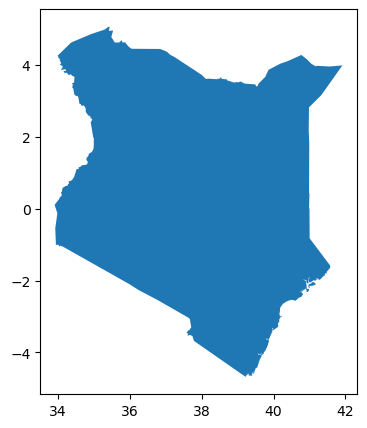

In [6]:
regions = (
    os.getcwd() + "/pypsa-earth/resources" + "/" + scenario_subpath + "/shapes/country_shapes.geojson"
)  # path of the input as shown in the Snakefile
gpd.read_file(regions).plot(figsize=(5,5))

That's how the raw data looks like:

In [7]:
gpd.read_file(regions)

,name,geometry
0,KE,"MULTIPOLYGON (((39.2193 -4.67578, 37.7858 -3.6771, 37.74409 -3.544..."


Checking which countries are considered:

In [8]:
n.buses["country"].unique()

array(['KE'], dtype=object)

Looking at the lines you find out that some of the names at the end of the pandadataframe are quite long. These are articifial created lines that create a connected network topology:

In [9]:
n.lines.head(2)

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,bounds,carrier,type,s_max_pu,s_nom,build_year,underwater_fraction,x,r,g,b,s_nom_mod,s_nom_extendable,s_nom_min,s_nom_max,capital_cost,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
Line,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3.0,132.0,40,20,NaN,False,"LINESTRING (37.0288 -0.4314, 37.028665199999985 -0.4307265, 37.027...","MULTIPOINT ((37.0288 -0.4314), (37.068 -0.0016))",AC,243-AL1/39-ST1A 20.0,0.7,442.400417,0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,220.0,42,1,NaN,False,"LINESTRING (36.9908 -1.2825, 36.976124 -1.2657485, 36.974339 -1.26...","MULTIPOINT ((36.9908 -1.2825), (36.916 -1.2579))",AC,Al/St 240/40 2-bundle 220.0,0.7,1474.668058,0,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,inf,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Check hv.plot (need to be fixed)

In [20]:
# Issue probably with ["geometry"]
n.lines["geometry"].head(2)  # .apply(wkt.loads)

Line
0    LINESTRING (37.0288 -0.4314, 37.028665199999985 -0.4307265, 37.027...
1    LINESTRING (36.9908 -1.2825, 36.976124 -1.2657485, 36.974339 -1.26...
Name: geometry, dtype: object

In [21]:
from shapely import wkt

lines = n.lines
lines["geometry"] = lines["geometry"].apply(wkt.loads)
lines = gpd.GeoDataFrame(lines, crs="epsg:4326")

buses = n.buses
buses["geometry"] = gpd.points_from_xy(buses.lon, buses.lat)
buses = gpd.GeoDataFrame(buses, crs="epsg:4326")

TypeError: Expected bytes or string, got LineString

In [16]:
lines = n.lines # lines[lines["country"] == "KE"]
buses = n. buses # buses[buses["country"] == "KE"]

basa_network = buses.hvplot(
    geo=True,
    size=10,  # buses["tag_area"]**(0.5)/10,
    frame_height=750,
    alpha=0.4,
    tiles="CartoLight",
    hover_cols=["bus_id"],
    color="orange",
) * lines.hvplot(geo=True, alpha=0.4, hover_cols=["line_id"]).opts(
    active_tools=["pan", "wheel_zoom"]
)
# display(basa_network) # show the plot in the notebook
hvplot.save(basa_network, "documentation/base_network_buses_lines.html");

KeyError: 'country'